# PCA — Variance and Covariance

*Course notes for **Math for Machine Learning**, C1 · W4 · L2 · V07a — "PCA: Variance and Covariance" (DeepLearning.AI).*

PCA rests on a few statistical ideas. This video reviews them:

- **Mean** — the center of the data.
- **Variance** — how spread out a single feature is.
- **Covariance** — the direction of the relationship between two features.

These are the ingredients PCA assembles (into a covariance matrix) to find the best projection directions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
%matplotlib inline

## 1. The mean

Each observation is a point $(x_i, y_i)$. The **mean** is the average of all observations — the center of the cloud, at $(\mu_x, \mu_y)$:

$$ \mu_x = \frac{1}{n}\sum_{i=1}^{n} x_i, \qquad \mu_y = \frac{1}{n}\sum_{i=1}^{n} y_i. $$

In [2]:
rng = np.random.default_rng(2)
n = 200
x = rng.normal(4, 2.5, n)          # wider spread
y = rng.normal(1, 0.8, n)          # narrower spread
data = np.column_stack([x, y])

mu = data.mean(axis=0)
print('mu_x, mu_y =', mu)

mu_x, mu_y = [3.981 0.964]


## 2. Variance — the spread of one feature

**Variance** measures how spread out a feature is: zero means no spread, larger means more. It's the **average squared distance from the mean** (dividing by $n-1$):

$$ \mathrm{Var}(x) = \frac{1}{n-1}\sum_{i=1}^{n} (x_i - \mu_x)^2. $$

**Worked example.** For $x = [5, 5, 9, 13, 13]$: the sum is $45$, so $\mu = 9$. The squared differences $16, 16, 0, 16, 16$ sum to $64$; dividing by $n-1 = 4$ gives a variance of $\mathbf{16}$.

In [3]:
sample = np.array([5, 5, 9, 13, 13])
mean = sample.mean()
sq_diffs = (sample - mean)**2
print('mean         =', mean)
print('squared diffs=', sq_diffs, ' sum =', sq_diffs.sum())
print('variance     =', sq_diffs.sum() / (len(sample) - 1))
print('np.var (ddof=1) =', np.var(sample, ddof=1))

mean         = 9.0
squared diffs= [16. 16.  0. 16. 16.]  sum = 64.0
variance     = 16.0
np.var (ddof=1) = 16.0


Var(x) = 5.818622623872949
Var(y) = 0.7108176875208853


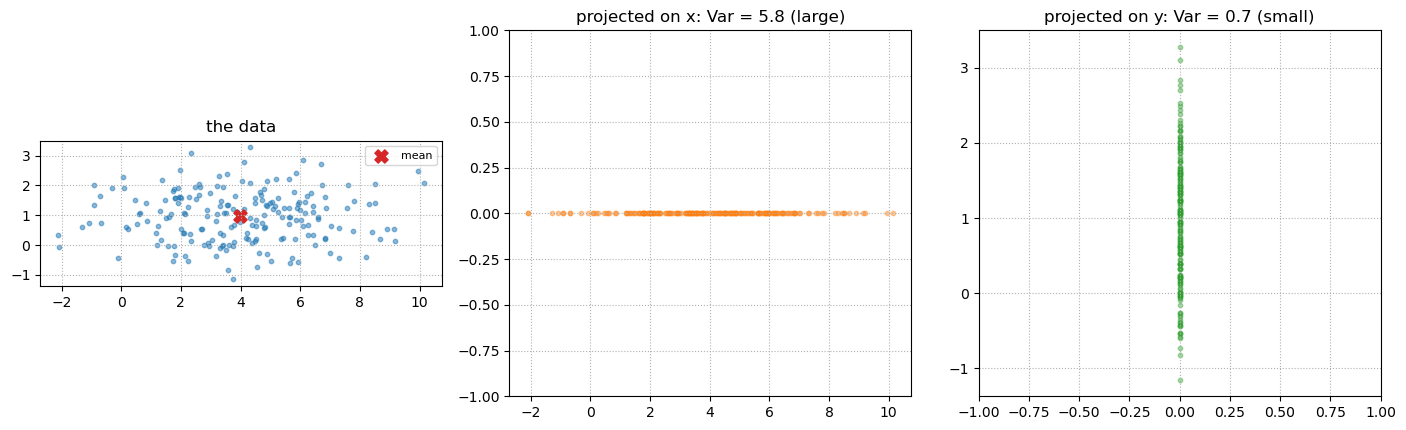

In [4]:
# In the 2-D cloud, x is more spread than y -> larger variance
print('Var(x) =', np.var(data[:, 0], ddof=1))
print('Var(y) =', np.var(data[:, 1], ddof=1))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
axes[0].scatter(data[:, 0], data[:, 1], s=10, color='C0', alpha=0.5)
axes[0].scatter(*mu, color='C3', s=90, marker='X', label='mean')
axes[0].set_title('the data'); axes[0].legend(fontsize=8); axes[0].set_aspect('equal')
# collapse onto x-axis
axes[1].scatter(data[:, 0], np.zeros(n), s=10, color='C1', alpha=0.4)
axes[1].set_title(f'projected on x: Var = {np.var(data[:,0], ddof=1):.1f} (large)')
axes[1].set_ylim(-1, 1)
# collapse onto y-axis
axes[2].scatter(np.zeros(n), data[:, 1], s=10, color='C2', alpha=0.4)
axes[2].set_title(f'projected on y: Var = {np.var(data[:,1], ddof=1):.1f} (small)')
axes[2].set_xlim(-1, 1)
for ax in axes: ax.grid(True, ls=':')
plt.tight_layout(); plt.show()

## 3. Why variance alone isn't enough

Two datasets can have **identical** $x$-variance and $y$-variance yet look completely different — one trending **down-right** (as $x$ grows, $y$ shrinks), the other **up-right** (both grow together). Variance can't tell them apart because it looks at each feature separately. We need a measure of how the two features **move together**: **covariance**.

## 4. Covariance — how two features vary together

$$ \mathrm{Cov}(x, y) = \frac{1}{n-1}\sum_{i=1}^{n} (x_i - \mu_x)(y_i - \mu_y). $$

It's almost the variance formula, but each term multiplies the $x$-deviation by the $y$-deviation. **Quadrant intuition:** re-center the data at $(\mu_x, \mu_y)$, splitting the plane into four quadrants. Each point contributes the sign of its deviation product:

| quadrant | $x-\mu_x$ | $y-\mu_y$ | product |
|---|---|---|---|
| top-right | $+$ | $+$ | **$+$** |
| top-left | $-$ | $+$ | **$-$** |
| bottom-left | $-$ | $-$ | **$+$** |
| bottom-right | $+$ | $-$ | **$-$** |

Covariance is (roughly) the **average** of these products — so it asks: are there more points in the **positive** quadrants or the **negative** ones?

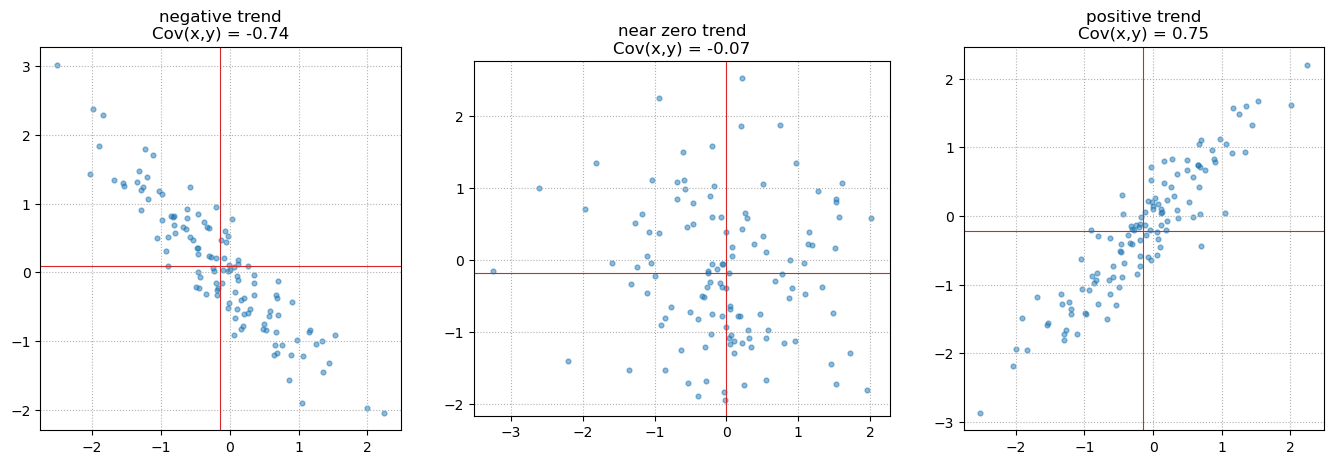

In [5]:
# Three datasets: negative, ~zero, and positive covariance
rng = np.random.default_rng(7)
m = 120
base = rng.normal(0, 1, m)
neg = np.column_stack([base, -base + rng.normal(0, 0.4, m)])   # down-right
zero = np.column_stack([rng.normal(0, 1, m), rng.normal(0, 1, m)])  # no relation
pos = np.column_stack([base,  base + rng.normal(0, 0.4, m)])   # up-right

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
for ax, d, ttl in [(axes[0], neg, 'negative'), (axes[1], zero, 'near zero'), (axes[2], pos, 'positive')]:
    c = np.cov(d.T, ddof=1)[0, 1]
    mx, my = d.mean(axis=0)
    ax.scatter(d[:, 0], d[:, 1], s=12, color='C0', alpha=0.5)
    ax.axvline(mx, color='C3', lw=0.8); ax.axhline(my, color='C3', lw=0.8)
    ax.set_aspect('equal'); ax.grid(True, ls=':')
    ax.set_title(f'{ttl} trend\nCov(x,y) = {c:.2f}')
plt.tight_layout(); plt.show()

## 5. Reading covariance

The most important takeaway is the **sign** — it gives the **direction of the relationship**:

- **negative** covariance → a **downward** trend (as $x$ increases, $y$ decreases),
- **near-zero** covariance → a **flat** trend / no linear relationship,
- **positive** covariance → an **upward** trend (both increase together).

Variances and covariances together (assembled into a **covariance matrix**, `np.cov`) are exactly what PCA uses next to find the best projection directions.

In [6]:
# The covariance matrix packages Var(x), Var(y), and Cov(x,y) together
C = np.cov(data.T, ddof=1)
print('covariance matrix:')
print(C)
print()
print('diagonal = variances :', np.diag(C))
print('off-diagonal = Cov(x,y):', C[0, 1])

covariance matrix:
[[5.819 0.034]
 [0.034 0.711]]

diagonal = variances : [5.819 0.711]
off-diagonal = Cov(x,y): 0.03437002023908229


## Summary

- **Mean** $(\mu_x, \mu_y)$ is the center of the data.
- **Variance** $= \frac1{n-1}\sum (x_i-\mu)^2$ is the average squared distance from the mean — larger spread, larger variance.
- Variance treats features separately, so it can't distinguish opposite trends; **covariance** $= \frac1{n-1}\sum (x_i-\mu_x)(y_i-\mu_y)$ measures how two features move **together**.
- The **sign** of covariance gives the trend direction: **negative** (down), **~0** (flat), **positive** (up) — via the quadrant/product intuition.
- Variances + covariances assemble into the **covariance matrix** (`np.cov`), the object PCA analyzes next.